<table style="width:100%">
  <tr>
    <td valign="top"><img src="../data/img/FER_logo_2.png" width=300 height=80 align="left"></td>
    <td valign="top"><img src="../data/img/LARES_2_transparent.png" width=250 height=80 align="right"></td>
  </tr>
 </table>

# Mall Customers - Unsupervised learning

## K-Means Clustering

Let's start with a simple presentation example and consider a dataset of mall customers and their characteristics: spending score and annual income.

Dataset available at: https://www.kaggle.com/shwetabh123/mall-customers

## Import modules

In [1]:
import numpy as np
import pandas as pd
import pickle
from sklearn.cluster import KMeans

In [2]:
import matplotlib.pyplot as plt

tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "serif",
    # Use 26pt font in plots
    "axes.labelsize": 16,
    "font.size": 16,
    "figure.titlesize": 16,
    # Make the legend/label fonts a little smaller
    "legend.title_fontsize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
}

plt.rcParams.update(tex_fonts)

#%pylab inline
%matplotlib inline
# %matplotlib notebook
%config InlineBackend.figure_format='svg'
plt.rcParams['figure.figsize'] = (10, 7)

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Auxiliary functions

In [4]:
# aux function for elbow method implementation
def elbow_method(X_train, n):
    wcss = []
    # calculate Within Cluster Sum of Squares (WCSS) for KMeans with 1-n clusters
    for i in range(1, n):
        kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
        kmeans.fit(X_train)
        wcss.append(kmeans.inertia_)
    
    fig = plt.figure(figsize = (10, 10))
    
    plt.plot(range(1, n), wcss)
    plt.title('The Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.show()


# aux function for plotting data with characterized clusters
def plot_clusters(X_train, y_kmeans, feat_1, feat_2):
    fig = plt.figure(figsize = (10, 10))
    for i, cluster_center in enumerate(model_kmeans.cluster_centers_):
        plt.scatter(X_train[y_kmeans == i, 0], X_train[y_kmeans == i, 1], s = 200, label = 'Cluster '+str(i+1))
    
    plt.scatter(model_kmeans.cluster_centers_[:, 0], model_kmeans.cluster_centers_[:, 1], s = 200, c = 'k', marker='x', label = 'Centroids')
    
    plt.title('Clusters')
    plt.xlabel(feat_1)
    plt.ylabel(feat_2)
    plt.legend()
    plt.show()

## Unsupervised learning
0. Preprocess data

1. Create/build model

2. Fit/Evaluate model

3. Hands on

## 0. (Pre)process data

In [5]:
dataset = pd.read_csv('../data/mall_customers/mall_customers.csv')

In [6]:
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


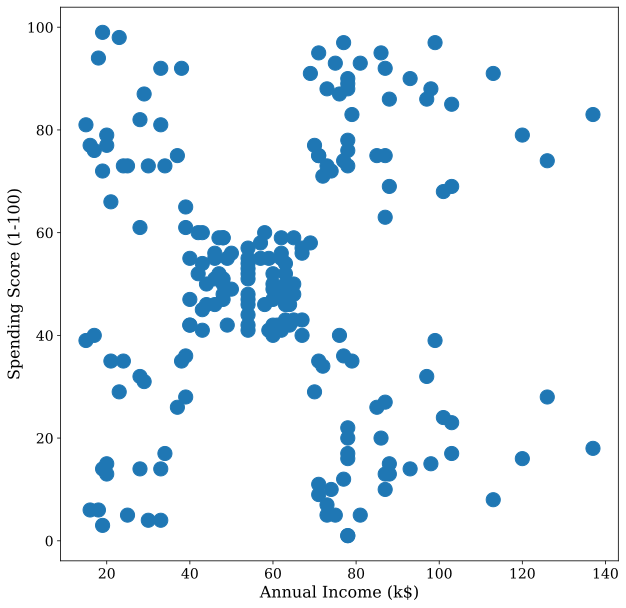

In [7]:
# choose only 'Annual Income (k$)' and 'Spending Score (1-100)' columns
X_train = dataset.loc[:, ['Annual Income (k$)', 'Spending Score (1-100)']].values
# simple scatter plot to visualize the data distribution
fig = plt.figure(figsize = (10, 10))
plt.scatter(X_train[:,0],X_train[:,1], s = 200)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

## Hands on
### Use the elbow method to find the optimal number of clusters

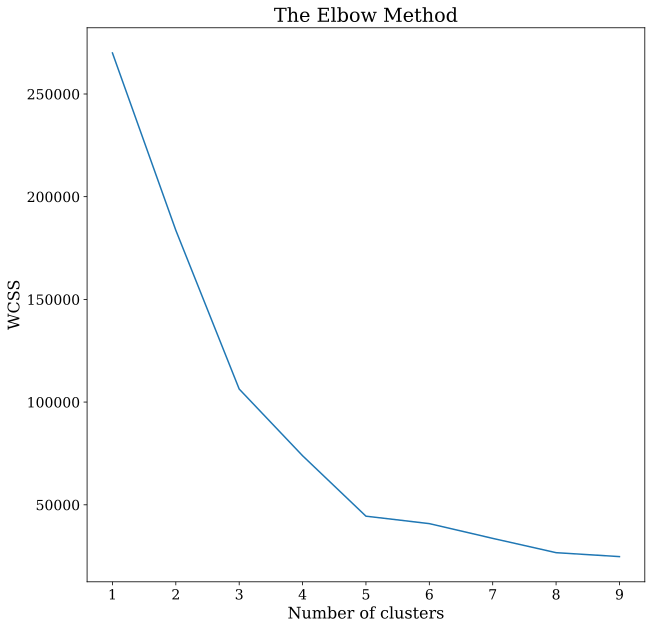

In [8]:
# HANDS ON
# # elbow method up to 10 clusters
# elbow_method(X_train, ??)

# elbow method up to 10 clusters
elbow_method(X_train, 10)

## 1. Create/build model

### Training the K-Means model on the dataset - based on the elbow method results

In [9]:
# HANDS ON
# # train K-Means model with 5 clusters (elbow method)
# model_kmeans = KMeans(??, ??, random_state = 42)

# train K-Means model with 5 clusters (elbow method)
model_kmeans = KMeans(n_clusters=5, init='k-means++', random_state = 42)

### 2. Fit/Evaluate model

In [10]:
# HANDS ON
# y_kmeans = ??

y_kmeans = model_kmeans.fit_predict(X_train)

### Visualize the clusters

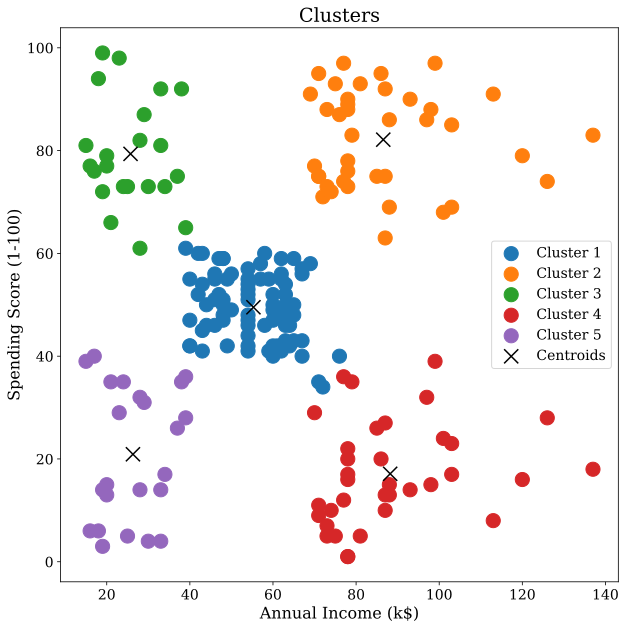

In [11]:
# plot the characterized clusters
plot_clusters(X_train, y_kmeans, 'Annual Income (k$)', 'Spending Score (1-100)')

In [12]:
# If you're satisfied with the model, save it to disk
filename = '../models/kmeans_mall_customers.pkl'
pickle.dump(model_kmeans, open(filename, 'wb'))
 
# load the model from disk
# model_kmeans = pickle.load(open(filename, 'rb'))
# result = model_kmeans.predict(X_test)

In [13]:
"""
Perform hierarchical clustering on samples using the
linkage() function with the method='complete' keyword argument.
Assign the result to mergings.
"""
from scipy.cluster.hierarchy import linkage, dendrogram

mergings = linkage(X_train, method='complete')
# mergings = linkage(samples, method='ward')

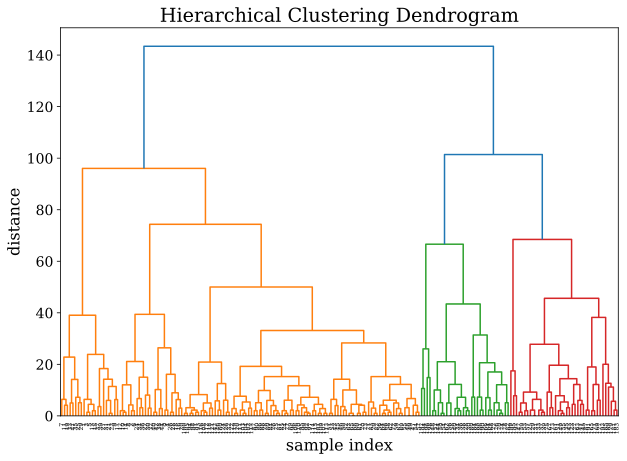

In [14]:
"""
Plot a dendrogram using the dendrogram() function on mergings,
specifying the keyword arguments labels=varieties, leaf_rotation=90,
and leaf_font_size=6.
"""
fig, ax = plt.subplots()

dendrogram(mergings,
           ax=ax,
           leaf_rotation=90,
           leaf_font_size=6,
           )

ax.set_title('Hierarchical Clustering Dendrogram')
ax.set_xlabel('sample index')
ax.set_ylabel('distance')

# ax.set_xlim([0, 1500])

plt.show()

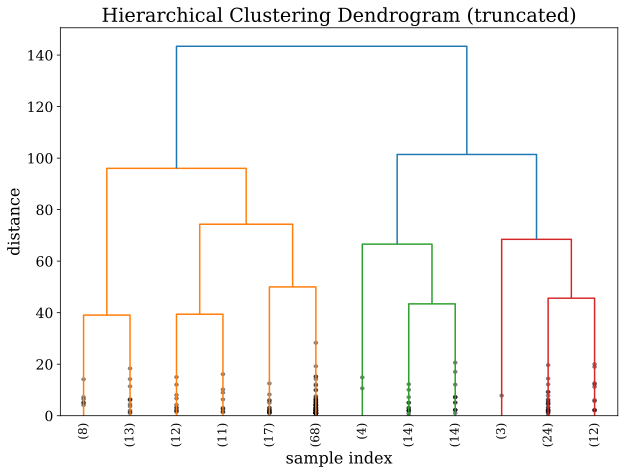

In [15]:
fig, ax = plt.subplots()

dendrogram(
    mergings,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=12,  # show only the last p merged clusters
    show_leaf_counts=True,  # otherwise numbers in brackets are counts
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)

ax.set_title('Hierarchical Clustering Dendrogram (truncated)')
ax.set_xlabel('sample index')
ax.set_ylabel('distance')

plt.show()



_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 3a_Clustering_Mall_customers_  
_Instructors: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_  
_Intended user: XY_  
_Date: 1st January 1991_  

_References:_
- _Python Software Foundation (2024). Python 3.12.7 documentation, https://docs.python.org/3.12/_
- _Anaconda Inc. (2024). Anaconda documentation, https://docs.anaconda.com/_

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_

